In [21]:
using LinearAlgebra, SparseArrays, Parameters, LinearMaps, Plots, Serialization
plotlyjs()   # Enables interactive rotation


Plots.PlotlyJSBackend()

In [2]:
# #1D Matrix operator utility functions.
# spI(n) = spdiagm(n,n, 0 => ones(n))
# ∂1d(n,dx) = spdiagm(n,n+1,0 => -ones(n), 1 => ones(n))/dx
# c(n) = spdiagm(n,n+1,0 => ones(n), 1 => ones(n))/2
# χ(n) = spdiagm(n,n+2, 1 => ones(n))


In [3]:
# A = spI(5)
# rank(∂1d(5,0.1))
# ∂1d(5,0.1)

In [27]:
# Define parameters
Base.@kwdef struct Params
    left_x_BC::String = "traction" # or " Dirichlet"
    right_x_BC::String = "traction" # or " Dirichlet"
    y_BC::String = "traction_free" # "Neumann" or "traction_free"
    k::Float64 = 1e-8       # small numerical factor
    λ::Float64 = 1.0
    μ::Float64 = 1.0
    Lx::Float64 = 1.0
    Nx::Int = 15
    Δx::Float64 = Lx/(Nx-1) # spatial step
    Ly::Float64 = 1.0
    Ny::Int = 16
    Δy::Float64 = Ly/(Ny-1) # spatial step
    T::Int = 10 + 1         # number of steps for pseudotime
    dt::Float64 = 1/(T-1)   # step in pseudotime
    tol::Float64 = 1e-6     # convergence tolerance
    max_iter::Int = 20      # max staggered iterations
    savefile::String = "sol.jls" # file to save iterations
    l::Float64 = 0.1 # regularization length for phase field
    C3::Float64 = 1.0 # constant for phase field eq.
    """ 
    parameter for star-convex energy split
    with γstar>=-1, γstar=-1 is standard model and γstar=0 -s volumetric-deviatoric split
    """
    γstar::Float64 = 0.0  
end

# ------------------------------------------------------------
# Grid indexing (column major)
# ------------------------------------------------------------
lin(i,j,Nx) = i + (j-1)*Nx

# ------------------------------------------------------------
# Derivatives (1st order boundary, 2nd interior)
# ------------------------------------------------------------
function Dx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[i+1,j] - f[i,j]) / Δx
    elseif i == Nx
        return (f[i,j] - f[i-1,j]) / Δx
    else
        return (f[i+1,j] - f[i-1,j]) / (2Δx)
    end
end

function Dy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,j+1] - f[i,j]) / Δy
    elseif j == Ny
        return (f[i,j] - f[i,j-1]) / Δy
    else
        return (f[i,j+1] - f[i,j-1]) / (2Δy)
    end
end

function Dxx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[1,j] - 2*f[2,j] + f[3,j]) / Δx^2
    elseif i == Nx
        return (f[Nx-2,j] - 2*f[Nx-1,j] + f[Nx,j]) / Δx^2
    else
        return (f[i-1,j] - 2*f[i,j] + f[i+1,j]) / Δx^2
    end
end

function Dyy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,1] - 2*f[i,2] + f[i,3]) / Δy^2
    elseif j == Ny
        return (f[i,Ny-2] - 2*f[i,Ny-1] + f[i,Ny]) / Δy^2
    else
        return (f[i,j-1] - 2*f[i,j] + f[i,j+1]) / Δy^2
    end
end

# degradation function
function g(d,i,j,p::Params)
    return (1.0-d[i,j])^2 + p.k
end

# Build Q,P coefficients after linearization
function build_QP(d,a1_bar,a2_bar,p::Params)

    Nx = p.Nx
    Ny = p.Ny
    λ,μ = p.λ,p.μ

    Q111 = zeros(Nx,Ny)
    P111 = zeros(Nx,Ny)
    Q112 = zeros(Nx,Ny)
    P112 = zeros(Nx,Ny)

    Q121 = zeros(Nx,Ny)
    P121 = zeros(Nx,Ny)
    Q122 = zeros(Nx,Ny)
    P122 = zeros(Nx,Ny)

    Q221 = zeros(Nx,Ny)
    P221 = zeros(Nx,Ny)
    Q222 = zeros(Nx,Ny)
    P222 = zeros(Nx,Ny)

    for j in 1:Ny
        for i in 1:Nx

            a1barx  = Dx(a1_bar,i,j,p)
            a1bary  = Dy(a1_bar,i,j,p)
            a2barx  = Dx(a2_bar,i,j,p)
            a2bary  = Dy(a2_bar,i,j,p)

            # pressure
            pres = (a1barx + a2bary)
            # mask
            if pres <= 0 
                mp = 1.0 + p.γstar*(1.0 - g(d, i, j, p))
            else    
                mp = g(d, i, j, p)
            end

            # # from linearisation
            # fbar = sqrt((a1barx - a2bary)^2 + (a1bary + a2barx)^2)

            # if fbar == 0.0 # strictly
            #     r1x = 1/6 - 1/(2^(3/2))
            #     r1y = -1/(2^(3/2))
            #     r2x = -1/(2^(3/2))
            #     r2y = 1/6 + 1/(2^(3/2))
            # else
            #     r1x = 1/6 - (a1barx - a2bary)/(2fbar)
            #     r1y = -(a1bary + a2barx)/(2fbar)
            #     r2x = -(a1bary + a2barx)/(2fbar)
            #     r2y = 1/6 + (a1barx - a2bary)/(2fbar)
            # end

            # q1 = (a1barx + a2bary)/6 - 0.5*fbar
            # q2 = (a1barx + a2bary)/6 + 0.5*fbar
            # # masks
            # m_q1 = q1 <= 0 ? 1.0 : g(d, i, j, p)
            # m_q2 = q2 <= 0 ? 1.0 : g(d, i, j, p)

            # coefficients
            # for a1x
            Q111[i,j] = (λ + 2*μ/3)*mp + 4*g(d,i,j,p)*μ/3 #λ + 2*μ
            # for a1y
            #P111[i,j] = 
            # for a2x 
            Q112[i,j] = (λ + 2*μ/3)*mp
            # for a2y
            P112[i,j] = -2*g(d,i,j,p)*μ/3 #λ

            #Q121[i,j] = 
            P121[i,j] = g(d,i,j,p)*μ #μ 
            Q122[i,j] = g(d,i,j,p)*μ #μ
            #P122[i,j] = 

            Q221[i,j] = (λ + 2*μ/3)*mp - 2*g(d,i,j,p)*μ/3 # λ
            #P221[i,j] = 
            Q222[i,j] = (λ + 2*μ/3)*mp
            P222[i,j] = 4*g(d,i,j,p)*μ/3 # λ + 2*μ
        end
    end

    return Q111,P111,Q112, P112,
           Q121,P121,Q122,P122,
           Q221,P221,Q222,P222
end

# Build global matrix M and rhs b
function build_system(Q111,P111,Q112,P112,
                      Q121,P121,Q122,P122,
                      Q221,P221,Q222,P222,
                      p::Params,
                      f1_left, f1_right,
                      f2_left, f2_right,
                      x,y)

    Nx,Ny = p.Nx,p.Ny
    Δx,Δy = p.Δx,p.Δy
    Ntot = Nx*Ny # a1, a2 are vectorized
    Ndof = 2*Ntot # for both a1 and a2

    λ, μ = p.λ, p.μ

    M = zeros(Ndof,Ndof)
    b = zeros(Ndof)

    # BC in x
    # left
    if p.left_x_BC=="Dirichlet"
        # for i = 1
        for j in 1:Ny
            k = lin(1,j,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1]=1; b[k1]=f1_left[j] # grid function of y
            M[k2,k2]=1; b[k2]=f2_left[j]
        end
    elseif p.left_x_BC=="traction"
        # for i = 1
        # for j=2 we apply another constraint to remove rotation
        for j in 2:Ny-1
            k = lin(1,j,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = f1_left
            # tensile/compressive
            # (λ+2μ)∂_x a1 # forward FD
            M[k1,k1]= (λ+2μ)*(-1/Δx)
            M[k1,lin(2,j,Nx)]= (λ+2μ)*(1/Δx) 
            # + λ ∂_y a2 # centred FD
            M[k1,Ntot+lin(1,j-1,Nx)] = μ*(-0.5/Δy)
            M[k1,Ntot+lin(1,j+1,Nx)] = μ*(0.5/Δy)
            # prescribed f1_left
            b[k1] = -f1_left[j] 
            # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
            # μ ∂_y a1; centred FD
            M[k2,lin(1,j-1,Nx)] = μ*(-0.5/Δy)
            M[k2,lin(1,j+1,Nx)] = μ*(0.5/Δy)
            # + μ ∂_x a2; forward FD
            M[k2,Ntot+lin(1,j,Nx)] = μ*(-1/Δx)
            M[k2,Ntot+lin(2,j,Nx)] = μ*(1/Δx)
            # prescribed f2_left
            b[k2] = -f2_left[j]
        end
        
        """
        does not work well; there are 3 dofs related to rigid body motion to be fixed that I cannot do well yet. Below is a failed attempt
        """
        # -------------------------------------------------------------------------
        # pin the corner i=1,j=1 to remove translations (traction prescribes derivatives only; there is residual gauge freedom)
        # -------------------------------------------------------------------------
        # k = lin(1,1,Nx)
        # k1 = k # for a1 positions in vector [a1, a2]
        # k2 = k + Ntot # for a2...
        # M[k1,k1]=1; b[k1] = 0.0
        # M[k2,k2]=1; b[k2] = 0.0

        # # pin also top left corner; fail
        # k = lin(1,Ny,Nx)
        # k1 = k # for a1 positions in vector [a1, a2]
        # k2 = k + Ntot # for a2...
        # M[k1,k1]=1; b[k1] = 0.0
        # M[k2,k2]=1; b[k2] = 0.0
        
        # # -------------------------------------------------------------------------
        # # at i=1,j=2 impose zero rotation i.e x*u2-y*u1 = 0, to remove 1 dof
        # # -------------------------------------------------------------------------
        # k = lin(1,2,Nx)
        # k1 = k # for a1 positions in vector [a1, a2]
        # k2 = k + Ntot # for a2...
        # M[k1,k1] += 1.0#-y[2] # coef of a1 
        # M[k2,k2] += 1.0#x[1] # coef of a2
        # b[k1] = 0.0
        # b[k2] = 0.0
        # # # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # # # μ ∂_y a1; centred FD
        # # M[k2,lin(1,1,Nx)] = μ*(-0.5/Δy)
        # # M[k2,lin(1,3,Nx)] = μ*(0.5/Δy)
        # # # + μ ∂_x a2; forward FD
        # # M[k2,Ntot+lin(1,2,Nx)] = μ*(-1/Δx)
        # # M[k2,Ntot+lin(2,2,Nx)] = μ*(1/Δx)
        # # # prescribed f2_left
        # # b[k2] = f2_left[2]
        
        # -------------------------------------------------------------------------
        # on the 2 corners use forward and backward FD for ∂_y
        # -------------------------------------------------------------------------
        # i=1,j=1
        k = lin(1,1,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = f1_left
        # tensile/compressive
        # (λ+2μ)∂_x a1 # forward FD
        M[k1,k1]= (λ+2μ)*(-1/Δx)
        M[k1,lin(2,1,Nx)]= (λ+2μ)*(1/Δx) 
        # + λ ∂_y a2 # forward FD
        M[k1,Ntot+lin(1,1,Nx)] = μ*(-1/Δy)
        M[k1,Ntot+lin(1,2,Nx)] = μ*(1/Δy)
        # prescribed f1_left
        b[k1] = -f1_left[1] 
        # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # μ ∂_y a1; forward FD
        M[k2,lin(1,1,Nx)] = μ*(-1/Δy)
        M[k2,lin(1,2,Nx)] = μ*(1/Δy)
        # + μ ∂_x a2; forward FD
        M[k2,Ntot+lin(1,1,Nx)] = μ*(-1/Δx)
        M[k2,Ntot+lin(2,1,Nx)] = μ*(1/Δx)
        # prescribed f2_left
        b[k2] = -f2_left[1]
        
        # -------------------------------------------------------------------------
        # i=1,j=Ny
        # -------------------------------------------------------------------------
        
        k = lin(1,Ny,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = f1_left
        # tensile/compressive
        # (λ+2μ)∂_x a1 # forward FD
        M[k1,k1]= (λ+2μ)*(-1/Δx)
        M[k1,lin(2,Ny,Nx)]= (λ+2μ)*(1/Δx) 
        # + λ ∂_y a2 # backward FD
        M[k1,Ntot+lin(1,Ny-1,Nx)] = μ*(-1/Δy)
        M[k1,Ntot+lin(1,Ny,Nx)] = μ*(1/Δy)
        # prescribed f1_left
        b[k1] = -f1_left[Ny] 
        # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # μ ∂_y a1; backward FD
        M[k2,lin(1,Ny-1,Nx)] = μ*(-1/Δy)
        M[k2,lin(1,Ny,Nx)] = μ*(1/Δy)
        # + μ ∂_x a2; forward FD
        M[k2,Ntot+lin(1,Ny,Nx)] = μ*(-1/Δx)
        M[k2,Ntot+lin(2,Ny,Nx)] = μ*(1/Δx)
        # prescribed f2_left
        b[k2] = -f2_left[Ny]
    
    else
        println("no such left_x_BC")
    end
    # right BC
    if p.right_x_BC=="Dirichlet"
        # for i = Nx
        for j in 1:Ny
            k = lin(Nx,j,Nx)
            k1 = k # for a1
            k2 = k + Ntot # for a2
            M[k1,k1]=1; b[k1]=f1_right[j] # grid function of y
            M[k2,k2]=1; b[k2]=f2_right[j]
        end
    elseif p.right_x_BC=="traction"
        # for i = Nx
        for j in 2:Ny-1
            k = lin(Nx,j,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = t11
            # tensile/compressive
            # (λ+2μ)∂_x a1 # backward FD
            M[k1,k1]= (λ+2μ)*(1/Δx);
            M[k1,lin(Nx-1,j,Nx)]= (λ+2μ)*(-1/Δx); 
            # + λ ∂_y a2 # centred FD
            M[k1,Ntot+lin(Nx,j-1,Nx)] = μ*(-0.5/Δy)
            M[k1,Ntot+lin(Nx,j+1,Nx)] = μ*(0.5/Δy)
            # prescribed f1_right
            b[k1] = f1_right[j] 
            # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
            # μ ∂_y a1; centred FD
            M[k2,lin(Nx,j-1,Nx)] = μ*(-0.5/Δy)
            M[k2,lin(Nx,j+1,Nx)] = μ*(0.5/Δy)
            # + μ ∂_x a2; backward FD
            M[k2,Ntot+lin(Nx-1,j,Nx)] = μ*(-1/Δx)
            M[k2,Ntot+lin(Nx,j,Nx)] = μ*(1/Δx)
            # prescribed f2_right
            b[k2] = f2_right[j]
        end
        # for the corners
        # i=Nx,j=1
        k = lin(Nx,1,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = t11
        # tensile/compressive
        # (λ+2μ)∂_x a1 # backward FD
        M[k1,k1]= (λ+2μ)*(1/Δx);
        M[k1,lin(Nx-1,1,Nx)]= (λ+2μ)*(-1/Δx); 
        # + λ ∂_y a2 # forward FD
        M[k1,Ntot+lin(Nx,1,Nx)] = μ*(-1/Δy)
        M[k1,Ntot+lin(Nx,2,Nx)] = μ*(1/Δy)
        # prescribed f1_right
        b[k1] = f1_right[1] 
        # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # μ ∂_y a1; forward FD
        M[k2,lin(Nx,1,Nx)] = μ*(-1/Δy)
        M[k2,lin(Nx,2,Nx)] = μ*(1/Δy)
        # + μ ∂_x a2; backward FD
        M[k2,Ntot+lin(Nx-1,1,Nx)] = μ*(-1/Δx)
        M[k2,Ntot+lin(Nx,1,Nx)] = μ*(1/Δx)
        # prescribed f2_right
        b[k2] = f2_right[1]
        # i=Nx,j=Ny
        k = lin(Nx,Ny,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = t11
        # tensile/compressive
        # (λ+2μ)∂_x a1 # backward FD
        M[k1,k1]= (λ+2μ)*(1/Δx);
        M[k1,lin(Nx-1,Ny,Nx)]= (λ+2μ)*(-1/Δx); 
        # + λ ∂_y a2 # backward FD
        M[k1,Ntot+lin(Nx,Ny-1,Nx)] = μ*(-1/Δy)
        M[k1,Ntot+lin(Nx,Ny,Nx)] = μ*(1/Δy)
        # prescribed f1_right
        b[k1] = f1_right[Ny] 
        # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # μ ∂_y a1; backward FD
        M[k2,lin(Nx,Ny-1,Nx)] = μ*(-1/Δy)
        M[k2,lin(Nx,Ny,Nx)] = μ*(1/Δy)
        # + μ ∂_x a2; backward FD
        M[k2,Ntot+lin(Nx-1,Ny,Nx)] = μ*(-1/Δx)
        M[k2,Ntot+lin(Nx,Ny,Nx)] = μ*(1/Δx)
        # prescribed f2_right
        b[k2] = f2_right[Ny]
    else
        println("no such right_x_BC")
    end

    
    # BC in y
    if p.y_BC=="Neumann" # using 1st order stencils
        # for j=1
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,1,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = -1/Δy
            M[k1,lin(i,2,Nx)] = 1/Δy
            M[k2,k2] = -1/Δy
            M[k2,lin(i,2,Nx)+Ntot] = 1/Δy
        end
        # for j=Ny
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,Ny,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = 1/Δy
            M[k1,lin(i,Ny-1,Nx)] = -1/Δy
            M[k2,k2] = 1/Δy
            M[k2,lin(i,Ny-1,Nx)+Ntot] = -1/Δy
        end
    elseif p.y_BC == "traction_free"
        # for j=1
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,1,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_12 = 0 (μ*∂_y*a1 + μ*∂_x*a2 = 0)
            M[k1,k1] = μ*(-1/Δy)
            M[k1,lin(i,2,Nx)] = μ*(1/Δy)
            M[k1,lin(i+1,1,Nx)+Ntot] = μ*(1/(2*Δx))
            M[k1,lin(i-1,1,Nx)+Ntot] = μ*(-1/(2*Δx))
            # for sigma_22 = 0 (λ*∂_x*a1 + (λ+2μ)*∂_y*a2 = 0)
            M[k2,lin(i+1,1,Nx)] = λ*(1/(2*Δx))
            M[k2,lin(i-1,1,Nx)] = λ*(-1/(2*Δx))
            M[k2,k2] = (λ+2*μ)*(-1/Δy)
            M[k2,lin(i,2,Nx)+Ntot] = (λ+2*μ)*(1/Δy)
        end
        # for j=Ny
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,Ny,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_12 = 0 (μ*∂_y*a1 + μ*∂_x*a2 = 0)
            M[k1,k1] = μ*(1/Δy)
            M[k1,lin(i,Ny-1,Nx)] = μ*(-1/Δy)
            M[k1,lin(i+1,Ny,Nx)+Ntot] = μ*(1/(2*Δx))
            M[k1,lin(i-1,Ny,Nx)+Ntot] = μ*(-1/(2*Δx))
            # for sigma_22 = 0 (λ*∂_x*a1 + (λ+2μ)*∂_y*a2 = 0)
            M[k2,lin(i+1,Ny,Nx)] = λ*(1/(2*Δx))
            M[k2,lin(i-1,Ny,Nx)] = λ*(-1/(2*Δx))
            M[k2,k2] = (λ+2*μ)*(1/Δy)
            M[k2,lin(i,Ny-1,Nx)+Ntot] = (λ+2*μ)*(-1/Δy)

        end
    else
        println("no such y_BC")
    end
    
    for j in 2:Ny-1
        for i in 2:Nx-1

            # midpoints in x
            # sigma_11
            P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
            P111_i_phalf_j = 0.5*(P111[i,j]   + P111[i+1,j])
            Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
            Q111_i_phalf_j = 0.5*(Q111[i,j]   + Q111[i+1,j])
            P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
            P112_i_phalf_j = 0.5*(P112[i,j]   + P112[i+1,j])
            Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
            Q112_i_phalf_j = 0.5*(Q112[i,j]   + Q112[i+1,j])
            # sigma_12
            P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
            P121_i_phalf_j = 0.5*(P121[i,j]   + P121[i+1,j])
            Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
            Q121_i_phalf_j = 0.5*(Q121[i,j]   + Q121[i+1,j])
            P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
            P122_i_phalf_j = 0.5*(P122[i,j]   + P122[i+1,j])
            Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
            Q122_i_phalf_j = 0.5*(Q122[i,j]   + Q122[i+1,j])

            # midpoints in y
            # sigma_12
            P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
            P121_i_j_phalf = 0.5*(P121[i,j]   + P121[i,j+1])
            Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
            Q121_i_j_phalf = 0.5*(Q121[i,j]   + Q121[i,j+1])
            P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
            P122_i_j_phalf = 0.5*(P122[i,j]   + P122[i,j+1])
            Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
            Q122_i_j_phalf = 0.5*(Q122[i,j]   + Q122[i,j+1])
            # sigma_22
            P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
            P221_i_j_phalf = 0.5*(P221[i,j]   + P221[i,j+1])
            Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
            Q221_i_j_phalf = 0.5*(Q221[i,j]   + Q221[i,j+1])
            P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
            P222_i_j_phalf = 0.5*(P222[i,j]   + P222[i,j+1])
            Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
            Q222_i_j_phalf = 0.5*(Q222[i,j]   + Q222[i,j+1])

            k = lin(i,j,Nx)
            k1 = k # for a1
            k2 = k + Ntot # for a2

            # 1st eq; rhs = 0
            # for a1 part
            # a1_i-1_j-1
            M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i-1_j
            M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy)
            # a1_i-1_j+1
            M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
            # a1_i_j-1
            M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
            # a1_i,j
            M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2)
            # a1_i_j+1
            M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
            # a1_i+1_j-1
            M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i+1,j
            M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i+1_j+1
            M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
            
            # for a2 part
            # a2_i-1_j-1
            M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i-1_j
            M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy)
            # a2_i-1_j+1
            M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
            # a2_i_j-1
            M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
            # a2_i_j
            M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2)
            # a2_i_j+1
            M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
            # a2_i+1_j-1
            M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j
            M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j+1
            M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

            # 2nd eq; rhs = 0
            # for a1 part
            # a1_i-1_j-1
            M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i-1_j
            M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy)
            # a1_i-1_j+1
            M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
            # a1_i_j-1
            M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
            # a1_i,j
            M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2)
            # a1_i_j+1
            M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
            # a1_i+1_j-1
            M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i+1,j
            M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i+1_j+1
            M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
            
            # for a2 part
            # a2_i-1_j-1
            M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i-1_j
            M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy)
            # a2_i-1_j+1
            M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
            # a2_i_j-1
            M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
            # a2_i_j
            M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2)
            # a2_i_j+1
            M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
            # a2_i+1_j-1
            M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j
            M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j+1
            M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

        end
    end

    return M,b
end

build_system (generic function with 2 methods)

In [28]:
"""
using both traction in left/right does work well; there are dofs to be fixed related to rigid body motion that I have not found a good way to do yet
"""

p = Params(    
    left_x_BC = "traction", # "traction" 
    right_x_BC = "traction", # or "traction"
    y_BC="traction_free",
    λ = 1.0,
    μ = 1.0,
    Nx = 30,
    Ny = 30,
    max_iter = 1
)

Params("traction", "traction", "traction_free", 1.0e-8, 1.0, 1.0, 1.0, 30, 0.034482758620689655, 1.0, 30, 0.034482758620689655, 11, 0.1, 1.0e-6, 1, "sol.jls", 0.1, 1.0, 0.0)

In [29]:
a1 = zeros(p.Nx, p.Ny)
a2 = zeros(p.Nx, p.Ny)

a1_bar = copy(a1)
a2_bar = copy(a2)
d = copy(a2)

30×30 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

In [30]:
x = range(0,p.Lx,p.Nx)
y = range(0,p.Ly,p.Ny)
for j in 1:p.Ny
    for i in 1:p.Nx
        a1_bar[i,j] = 1e-1*sin(x[i])*cos(y[j])
        a2_bar[i,j] = 2*1e-1*cos(x[i])*sin(2*y[j])
    end
end

In [57]:
# heatmap(a2_bar,
# color = :coolwarm)   # Try :viridis, :inferno, :magma, :cividis)

In [31]:
Q111,P111,Q112,P112,
Q121,P121,Q122,P122,
Q221,P221,Q222,P222 =
    build_QP(d,a1_bar,a2_bar,p)

([3.00000003 3.00000003 … 3.000000013333333 3.000000013333333; 3.00000003 3.00000003 … 3.000000013333333 3.000000013333333; … ; 3.00000003 3.00000003 … 3.000000013333333 3.000000013333333; 3.00000003 3.00000003 … 3.000000013333333 3.000000013333333], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [1.666666683333333 1.666666683333333 … 1.6666666666666665 1.6666666666666665; 1.666666683333333 1.666666683333333 … 1.6666666666666665 1.6666666666666665; … ; 1.666666683333333 1.666666683333333 … 1.6666666666666665 1.6666666666666665; 1.666666683333333 1.666666683333333 … 1.6666666666666665 1.6666666666666665], [-0.6666666733333333 -0.6666666733333333 … -0.6666666733333333 -0.6666666733333333; -0.6666666733333333 -0.6666666733333333 … -0.6666666733333333 -0.6666666733333333; … ; -0.6666666733333333 -0.6666666733333333 … -0.6666666733333333 -0.6666666733333333; -0.6666666733333333 -0.6666666733333333 … -0.6666666733333333 -0.6666666733333333], [0.0 0.0 … 0.0 

In [32]:
f1_left  = -5.0*1e-1*ones(p.Ny)#0.0*ones(p.Ny)
f1_right = 5.0*1e-1*ones(p.Ny)
f2_left  = 0.0*1e-1*ones(p.Ny)
f2_right = 0.0*1e-1*ones(p.Ny)

30-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [33]:
M,b = build_system(
    Q111,P111,Q112,P112,
    Q121,P121,Q122,P122,
    Q221,P221,Q222,P222,
    p,
    f1_left,f1_right,
    f2_left,f2_right,
    x,y)

([-87.0 87.0 … 0.0 0.0; 0.0 -29.0 … 0.0 0.0; … ; 0.0 0.0 … 87.0 0.0; 0.0 0.0 … -29.0 29.0], [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [34]:
println("rank(M) = ", rank(M))
println("size(M) = ", size(M))
# println("det(M) = ", det(M))
# println("cond(M) = ", cond(M))

rank(M) = 1797
size(M) = (1800, 1800)


In [35]:
function build_constraints(x, y, Nx, Ny)

    Δx = x[2]-x[1]
    Δy = y[2]-y[1]
    N = Nx*Ny
    C = zeros(2N, 3)

    lin(i,j) = i + (j-1)*Nx

    for j in 1:Ny, i in 1:Nx
        k = lin(i,j)

        # mean ux
        C[k,1] = 1.0/N

        # mean uy
        C[N+k,2] = 1.0/N

        # rotation
        C[k,3]      = -y[j]/N
        C[N+k,3]    =  x[i]/N
    end

    return C
end

C = build_constraints(x,y,p.Nx,p.Ny)

gg = zeros(3)   # or set desired mean values

# induced aggregate x translation form x_BC
gg[1] = 0.5*(sum(f1_left) + sum(f1_right))/p.Ny
# induced aggregate y translation form x_BC
gg[2] = 0.5*(sum(f2_left) + sum(f2_right))/p.Ny
# induced aggregate rotation from x_BC: x*a2 - y*a1 is rotation
gg[3] = 0.5*(sum(x[1]*f2_left .- y.*f1_left) + sum(x[end]*f2_right .- y.*f1_right))/p.Ny

K = [M  C;
     C' zeros(3,3)]

rhs = [b;
       gg]

println(rank(K))
sol = K \ rhs

#u = sol[1:2N]

1803


1803-element Vector{Float64}:
 -0.09375000030392111
 -0.08728448305636148
 -0.08081896578481235
 -0.07435344852027308
 -0.06788793125380581
 -0.06142241398734279
 -0.05495689672067679
 -0.0484913794542121
 -0.0420258621882041
 -0.03556034492290472
 -0.02909482765852306
 -0.022629310395229023
 -0.016163793133178308
  ⋮
 -0.031250000540511774
 -0.031250000493297535
 -0.03125000044069469
 -0.031250000382061445
 -0.03125000031645245
 -0.03125000024290026
 -0.031250000158581766
 -0.03125000006516438
 -0.031249999939078104
  3.359188391028779e-7
  7.076976740497442e-7
 -4.325250553209747e-7

In [216]:
# #println(M[:,2])
# i = 50
# for j in findall(!iszero, M[i,:])
#     println("Index: $j, Value: ", M[i,j])
# end

In [217]:
# b[i]

In [148]:
# sol = (M) \ b

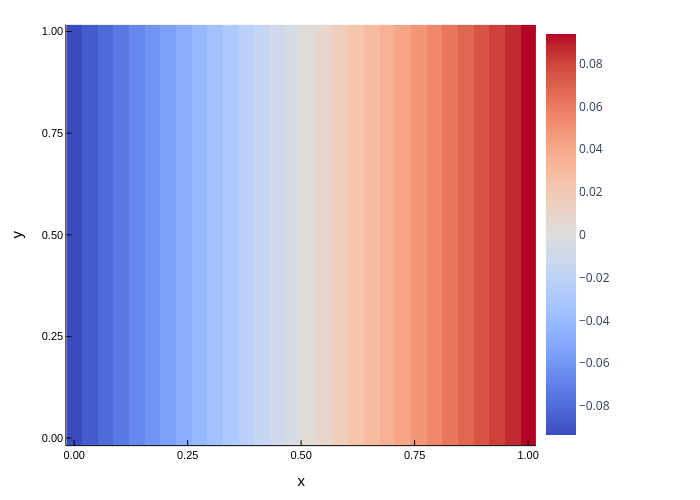

In [36]:
Ntot = p.Nx*p.Ny
a1sol = reshape(sol[1:Ntot], p.Nx, p.Ny)
heatmap(x,y,a1sol',
xlabel="x",
ylabel="y",
color=:coolwarm
)

In [242]:
# a1sol

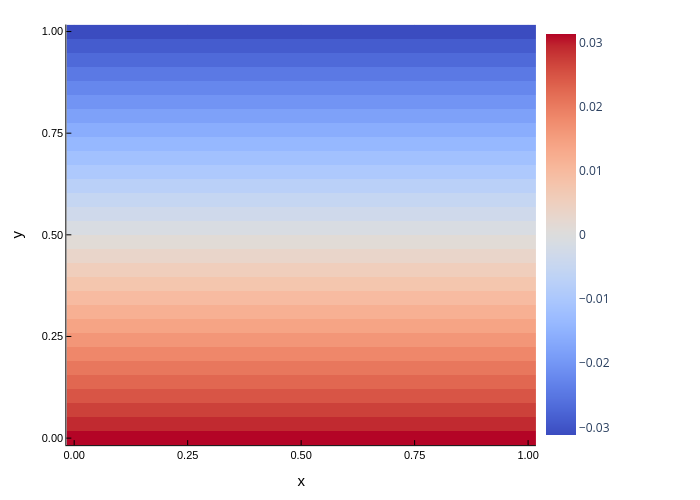

In [37]:
a2sol = reshape(sol[Ntot+1:2*Ntot], p.Nx, p.Ny)
heatmap(x,y, a2sol',
xlabel="x",
ylabel="y",
color=:coolwarm
)

In [109]:
# surface(x,y,a1sol',
# xlabel="x",
# ylabel="y",
# color=:coolwarm
# )

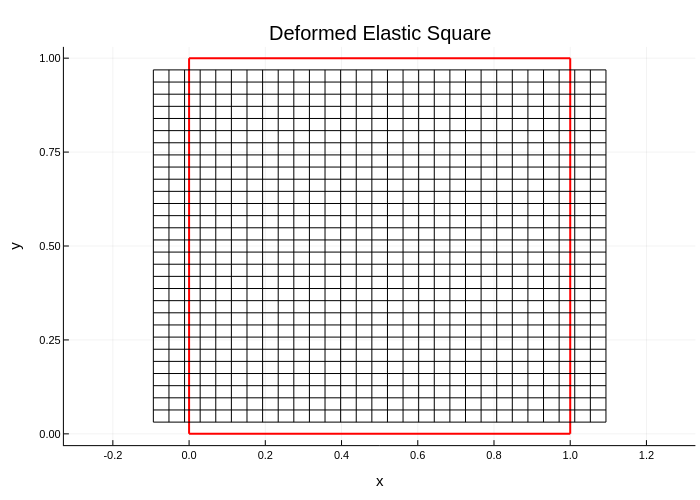

In [38]:
# Transpose for plotting consistency
a1p = a1sol'
a2p = a2sol'

# Build coordinate matrices
X = [xi for yi in y, xi in x]
Y = [yi for yi in y, xi in x]

# Deformed coordinates
Xd = X .+ a1p
Yd = Y .+ a2p

# Plot deformed grid
p1 = plot()

# --- add red boundary lines for original shape---

# bottom and top
plot!(X[1, :],    Y[1, :],    color=:red, lw=2)
plot!(X[end, :],  Y[end, :],  color=:red, lw=2)

# left and right
plot!(X[:, 1],    Y[:, 1],    color=:red, lw=2)
plot!(X[:, end],  Y[:, end],  color=:red, lw=2)

# horizontal lines
for i in 1:p.Ny
    plot!(Xd[i, :], Yd[i, :], color=:black, lw=1)
end

# vertical lines
for j in 1:p.Nx
    plot!(Xd[:, j], Yd[:, j], color=:black, lw=1)
end

plot!(
    aspect_ratio = 1,
    xlabel = "x",
    ylabel = "y",
    legend = false,
    title = "Deformed Elastic Square"
    
)

In [247]:
# -----------------------
# Check Poisson squeeze
# -----------------------
mid = div(p.Ny,2)
εx = (a1sol[end,mid] - a1sol[1,mid]) / p.Lx
εy = (a2sol[mid,p.Ny] - a2sol[mid,1]) / p.Ly

println("Measured Poisson ratio ≈ ", -εy/εx)
ν = p.λ/(2*(p.λ+p.μ))
println("Theoretical ν = ", ν)


Measured Poisson ratio ≈ -1.1896846831845076
Theoretical ν = 0.25


In [239]:
ν_apparent = ν/(1-ν)

0.3333333333333333

In [19]:
mid = div(p.Ny, 2)
band_halfwidth = div(p.Ny, 4)   # total width = Ny/2

j_start = max(1, mid - band_halfwidth)
j_end   = min(p.Ny, mid + band_halfwidth)

sum_right = 0.0
sum_left  = 0.0
count = 0

for j in j_start:j_end
    sum_right += a1sol[end, j]
    sum_left  += a1sol[1, j]
    count += 1
end

ux_right = sum_right / count
ux_left  = sum_left  / count

εx = (ux_right - ux_left) / p.Lx

mid_x = div(p.Nx, 2)
band_halfwidth_x = div(p.Nx, 4)

i_start = max(1, mid_x - band_halfwidth_x)
i_end   = min(p.Nx, mid_x + band_halfwidth_x)

sum_top = 0.0
sum_bottom = 0.0
count = 0

for i in i_start:i_end
    sum_top    += a2sol[i, end]
    sum_bottom += a2sol[i, 1]
    count += 1
end

uy_top    = sum_top / count
uy_bottom = sum_bottom / count

εy = (uy_top - uy_bottom) / p.Ly

println("Measured Poisson ratio ≈ ", -εy/εx)

Measured Poisson ratio ≈ 0.31966842201270246


In [144]:
function build_phase_field_sys(H, p::Params)

    Nx, Ny = p.Nx, p.Nx
    Δx, Δy = p.Δx, p.Δy
    l = p.l
    C3 = p.C3
    
    Ntot = Nx*Ny # d vectorized

    M = zeros(Ntot,Ntot)
    b = zeros(Ntot)

    for j in 2:Ny-1
        for i in 2:Nx-1
            k = lin(i,j,Nx)
            M[k,lin(i-1,j,Nx)] = 1/Δx^2
            M[k,lin(i,j-1,Nx)] = 1/Δy^2
            M[k,k] = -2/Δx^2 - 2/Δy^2 - 1/l^2 - 2*C3*H[i,j]/l
            M[k,lin(i,j+1,Nx)] = 1/Δy^2
            M[k,lin(i+1,j,Nx)] = 1/Δx^2
            b[k] = -2*C3*H[i,j]/l
        end
    end
    # BC is d*n = 0 -> d_x=0 on left/right and d_y=0 on top/bottom
    # Neumann with back/forward 1st order FD
    # for j=1; forward FD
    for i in 2:Nx-1
        k = lin(i,1,Nx)
        M[k,k] = -1/Δy
        M[k,lin(i,2,Nx)] = 1/Δy
    end
    # for j=Ny; backward FD
    for i in 2:Nx-1
        k = lin(i,Ny,Nx)
        M[k,k] = 1/Δy
        M[k,lin(i,Ny-1,Nx)] = -1/Δy
    end
    # for i=1; forward FD; includes corners i=1,j=1 and i=1,j=Ny
    for j in 1:Ny
        k = lin(1,j,Nx)
        M[k,k] = -1/Δx
        M[k,lin(2,j,Nx)] = 1/Δx
    end
    # for i=Nx; backward FD; includes corners i=Nx,j=1 and i=Nx,j=Ny
    for j in 1:Ny
        k = lin(Nx,j,Nx)
        M[k,k] = 1/Δx
        M[k,lin(Nx-1,j,Nx)] = -1/Δx
    end
    
    return M, b
end

build_phase_field_sys (generic function with 1 method)

In [20]:
function history_from_d(d, p::Params)

    Nx, Ny = p.Nx, p.Ny
    H = zeros(Nx,Ny)

    for j in 1:Ny
        for i in 1:Nx
            H[i,j] = (d[i,j] -p.l^2*(Dxx(d,i,j,p) + Dyy(d,i,j,p)))/(2*p.l*p.C3*(1-d[i,j]+p.k))
        end
    end

    return H
end

history_from_d (generic function with 1 method)

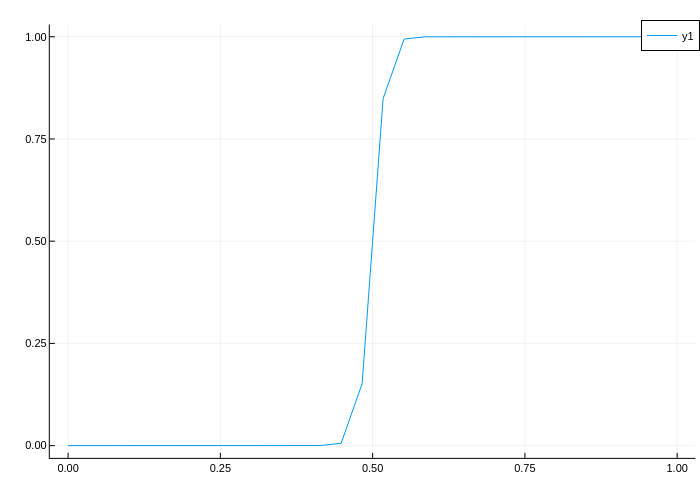

In [21]:
f0 = zeros(p.Ny)
f0 = 0.5*(1.0 .+ tanh.(50*(y .- 0.5)))
plot(y,f0)

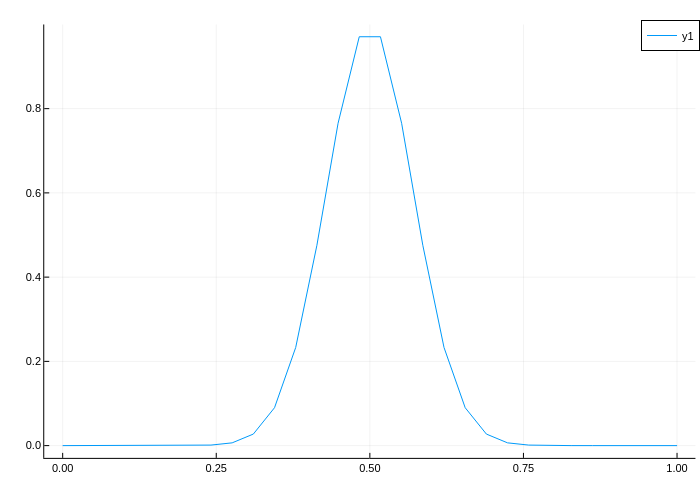

In [22]:
g0 = zeros(p.Nx)
g0 = exp.(-(x .- 0.5).^2/(2*0.005))
plot(x,g0)

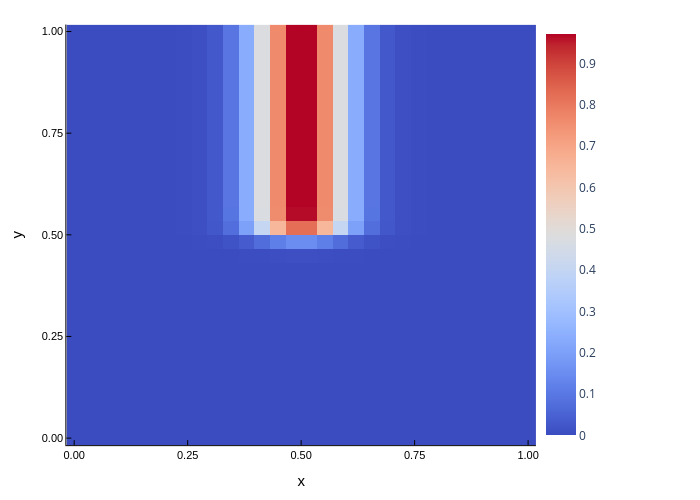

In [23]:
d0 = zeros(p.Nx, p.Ny)
for j in 1:p.Ny
    for i in 1:p.Nx
        d0[i,j] = g0[i]*f0[j]
    end
end

heatmap(x,y, d0',
xlabel="x",
ylabel="y",
color=:coolwarm
)

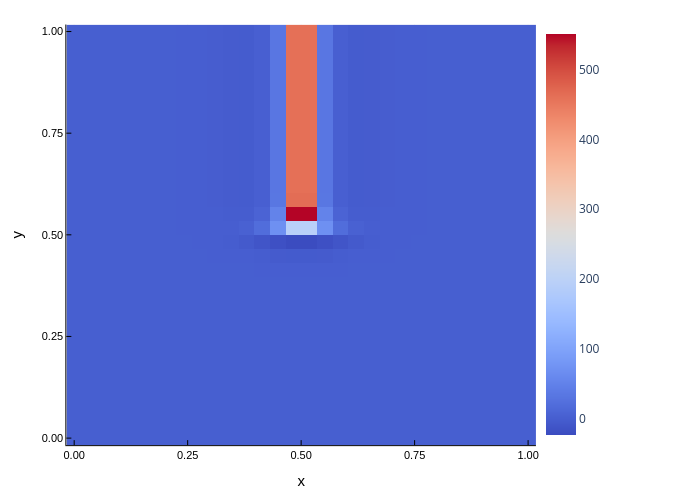

In [24]:
H0 = history_from_d(d0, p)

heatmap(x,y, H0',
xlabel="x",
ylabel="y",
color=:coolwarm
)

In [25]:
Md, bd = build_phase_field_sys(H0,p)

rank(Md)

LoadError: UndefVarError: `build_phase_field_sys` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

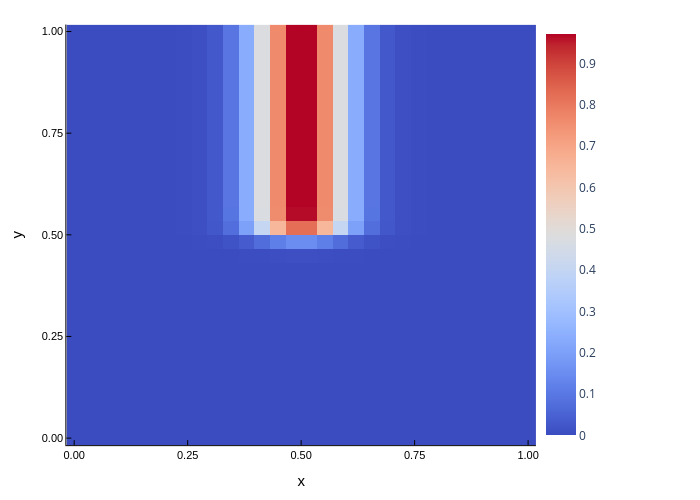

In [ ]:
dsol = Md \ bd
dsol = reshape(dsol, p.Nx, p.Ny)

heatmap(x,y, dsol',
xlabel="x",
ylabel="y",
color=:coolwarm
)

In [ ]:
maximum(dsol .- d0)

1.2853103023564863e-9

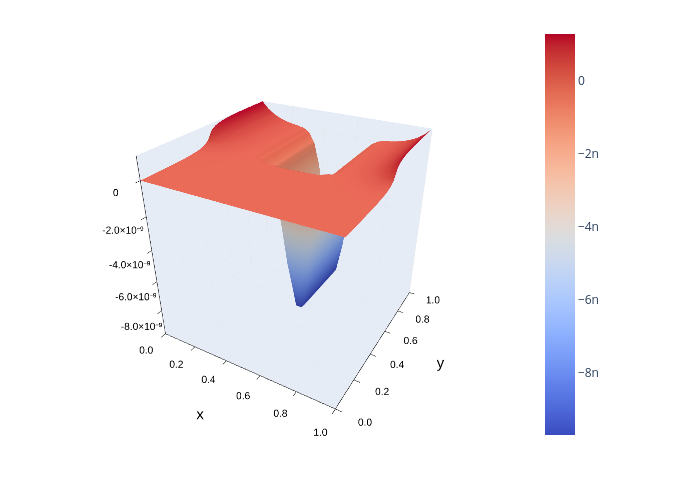

In [ ]:
surface(x,y, (dsol .- d0)',
xlabel="x",
ylabel="y",
color=:coolwarm
)

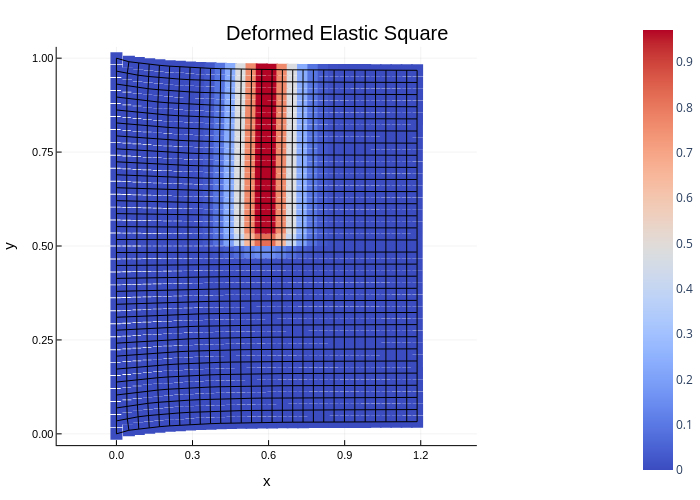

In [58]:
# transpose
a1p = a1sol'
a2p = a2sol'
d0p = d0'

Nx = length(x)
Ny = length(y)

# coordinate matrices
X = [xi for yi in y, xi in x]
Y = [yi for yi in y, xi in x]

# deformed coordinates
Xd = X .+ a1p
Yd = Y .+ a2p

plt = plot(
    aspect_ratio = 1,
    xlabel = "x",
    ylabel = "y",
    legend = false,
    title = "Deformed Elastic Square"
)

# node heatmap
scatter!(
    plt,
    vec(Xd),
    vec(Yd),
    marker = :square,
    marker_z = vec(d0p),
    ms = 6,
    color = :coolwarm,
    markerstrokewidth = 0,   # removes black circle border
    colorbar = true
)

# grid lines
for i in 1:Ny
    plot!(plt, Xd[i,:], Yd[i,:], color=:black, lw=1)
end

for j in 1:Nx
    plot!(plt, Xd[:,j], Yd[:,j], color=:black, lw=1)
end

display(plt)